In [13]:
import os
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling


# -----------------------------
# Input files
# -----------------------------

background_tif_path = "/Volumes/External/Old_Fire_Nowshin_Files/ge_2003_mosaic (1).tif"
raster_path = "/Volumes/External/Old_Fire_Nowshin_Files/USFS_images/rast_comp4band_261.tif"
shapefile_path = "/Volumes/External/OldFire/shapefiles/trees_polygon.shp"


# -----------------------------
# Output folder
# -----------------------------

output_folder = "/Volumes/External/OldFire/reprojected_4326"
os.makedirs(output_folder, exist_ok=True)

target_crs = "EPSG:4326"


# -----------------------------
# Helper function for rasters
# -----------------------------

def reproject_raster(input_path, output_folder, target_crs, resampling_method):
    """
    Reproject one raster to the target CRS.
    """

    filename = os.path.basename(input_path)
    name, ext = os.path.splitext(filename)

    output_path = os.path.join(output_folder, f"{name}_EPSG4326{ext}")

    with rasterio.open(input_path) as src:

        if src.crs is None:
            raise ValueError(f"{filename} does not have a CRS defined.")

        transform, width, height = calculate_default_transform(
            src.crs,
            target_crs,
            src.width,
            src.height,
            *src.bounds
        )

        kwargs = src.meta.copy()
        kwargs.update({
            "crs": target_crs,
            "transform": transform,
            "width": width,
            "height": height
        })

        with rasterio.open(output_path, "w", **kwargs) as dst:
            for band_idx in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, band_idx),
                    destination=rasterio.band(dst, band_idx),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=target_crs,
                    resampling=resampling_method
                )

    print(f"Saved reprojected raster: {output_path}")
    return output_path


# -----------------------------
# Reproject shapefile
# -----------------------------

gdf = gpd.read_file(shapefile_path)

if gdf.crs is None:
    raise ValueError("The shapefile does not have a CRS defined.")

gdf_4326 = gdf.to_crs(target_crs)

shapefile_name = os.path.splitext(os.path.basename(shapefile_path))[0]
output_shapefile_path = os.path.join(
    output_folder,
    f"{shapefile_name}_EPSG4326.shp"
)

gdf_4326.to_file(output_shapefile_path)

print(f"Saved reprojected shapefile: {output_shapefile_path}")


# -----------------------------
# Reproject background RGB tif
# -----------------------------

background_tif_4326 = reproject_raster(
    input_path=background_tif_path,
    output_folder=output_folder,
    target_crs=target_crs,
    resampling_method=Resampling.bilinear
)


# -----------------------------
# Reproject 4-band spectral raster
# -----------------------------

raster_4326 = reproject_raster(
    input_path=raster_path,
    output_folder=output_folder,
    target_crs=target_crs,
    resampling_method=Resampling.bilinear
)


print("\nDone.")
print("Use these files in the next scripts:")
print(f"background_tif_path = '{background_tif_4326}'")
print(f"raster_path = '{raster_4326}'")
print(f"shapefile_path = '{output_shapefile_path}'")

Saved reprojected shapefile: /Volumes/External/OldFire/reprojected_4326/trees_polygon_EPSG4326.shp
Saved reprojected raster: /Volumes/External/OldFire/reprojected_4326/ge_2003_mosaic (1)_EPSG4326.tif
Saved reprojected raster: /Volumes/External/OldFire/reprojected_4326/rast_comp4band_261_EPSG4326.tif

Done.
Use these files in the next scripts:
background_tif_path = '/Volumes/External/OldFire/reprojected_4326/ge_2003_mosaic (1)_EPSG4326.tif'
raster_path = '/Volumes/External/OldFire/reprojected_4326/rast_comp4band_261_EPSG4326.tif'
shapefile_path = '/Volumes/External/OldFire/reprojected_4326/trees_polygon_EPSG4326.shp'


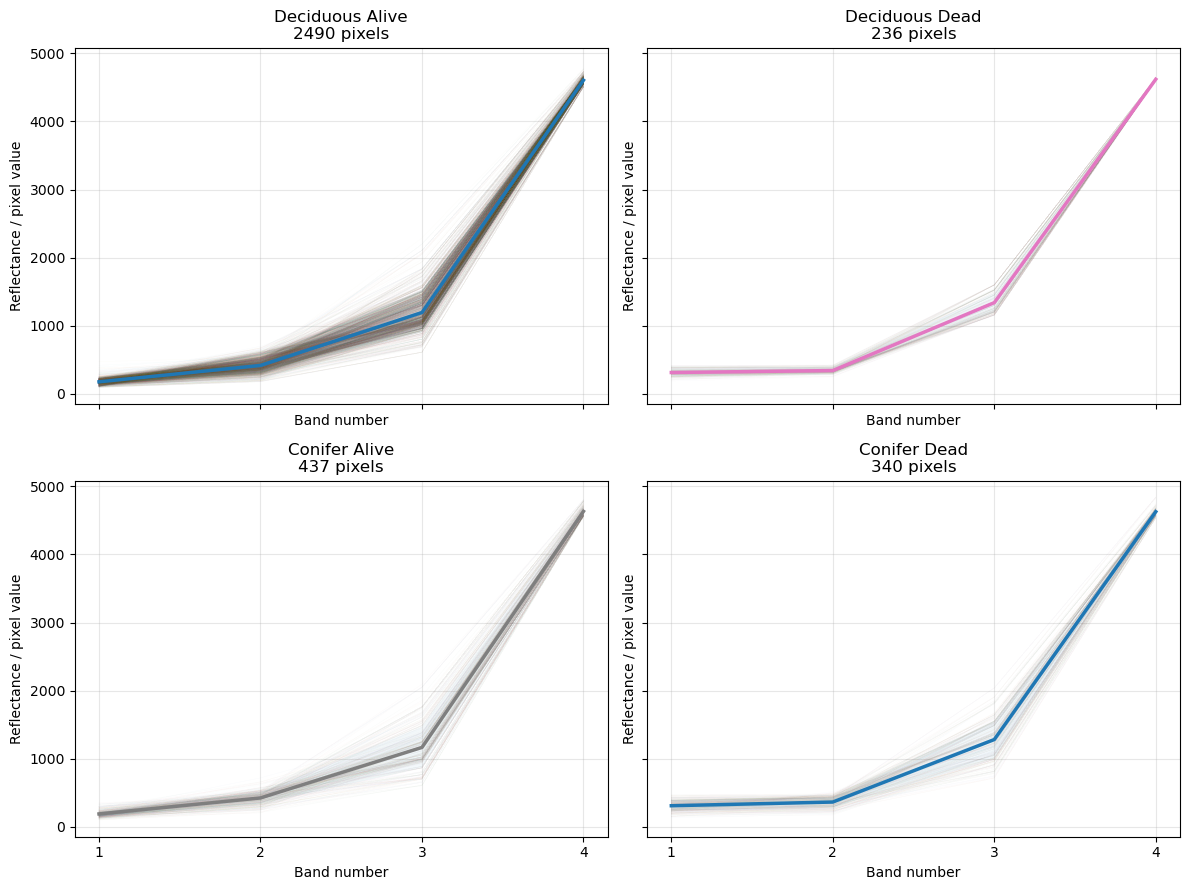

Saved plot to: /Volumes/External/OldFire/00_code/output/spectral_signatures_by_type_status.png


In [14]:
import os
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt


# -----------------------------
# User inputs
# -----------------------------

raster_path = "/Volumes/External/OldFire/reprojected_4326/rast_comp4band_261_EPSG4326.tif"
shapefile_path = "/Volumes/External/OldFire/reprojected_4326/trees_polygon_EPSG4326.shp"

output_dir = "/Volumes/External/OldFire/00_code/output"
os.makedirs(output_dir, exist_ok=True)

# Optional: replace these with real wavelengths if you know them.
# Example for Sentinel-2: [443, 490, 560, 665, 705, 740, 783, 842, 865, 1610, 2190]
wavelengths = None

# Maximum number of individual pixel spectra to draw per plot.
# This keeps plots readable and prevents huge files.
max_pixel_lines = 5000


# -----------------------------
# Helper function
# -----------------------------

def extract_pixels_for_group(src, polygons):
    """
    Extract valid pixel spectra from polygons for a multiband raster.

    Returns:
        pixels: array with shape (n_pixels, n_bands)
    """

    all_pixels = []

    for geom in polygons.geometry:
        try:
            out_image, out_transform = mask(
                src,
                [geom],
                crop=True,
                filled=True,
                nodata=src.nodata
            )
        except ValueError:
            # Polygon does not overlap raster
            continue

        # out_image shape: (bands, rows, cols)
        n_bands, rows, cols = out_image.shape

        # Reshape to: (pixels, bands)
        pixel_values = out_image.reshape(n_bands, rows * cols).T

        # Remove nodata pixels
        if src.nodata is not None:
            valid_mask = ~np.any(pixel_values == src.nodata, axis=1)
            pixel_values = pixel_values[valid_mask]

        # Remove NaN or infinite pixels
        valid_mask = np.all(np.isfinite(pixel_values), axis=1)
        pixel_values = pixel_values[valid_mask]

        # Remove pixels that are all zero, often background after masking
        nonzero_mask = ~np.all(pixel_values == 0, axis=1)
        pixel_values = pixel_values[nonzero_mask]

        if pixel_values.size > 0:
            all_pixels.append(pixel_values)

    if len(all_pixels) == 0:
        return np.empty((0, src.count))

    return np.vstack(all_pixels)


# -----------------------------
# Main script
# -----------------------------

# Read shapefile
gdf = gpd.read_file(shapefile_path)

# Make column names lowercase just in case
gdf.columns = [col.lower() for col in gdf.columns]

required_columns = ["type", "status"]
for col in required_columns:
    if col not in gdf.columns:
        raise ValueError(f"Missing required column: {col}")

# Clean category labels
gdf["type"] = gdf["type"].str.lower().str.strip()
gdf["status"] = gdf["status"].str.lower().str.strip()

groups = [
    ("deciduous", "alive"),
    ("deciduous", "dead"),
    ("conifer", "alive"),
    ("conifer", "dead")
]

with rasterio.open(raster_path) as src:

    # Reproject shapefile if needed
    if gdf.crs != src.crs:
        print("Reprojecting shapefile to match raster CRS...")
        gdf = gdf.to_crs(src.crs)

    n_bands = src.count

    if wavelengths is None:
        x_values = np.arange(1, n_bands + 1)
        x_label = "Band number"
    else:
        if len(wavelengths) != n_bands:
            raise ValueError(
                f"Length of wavelengths list must match raster band count. "
                f"Raster has {n_bands} bands, but wavelengths has {len(wavelengths)} values."
            )
        x_values = np.array(wavelengths)
        x_label = "Wavelength"

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, (veg_type, status) in zip(axes, groups):

        group_gdf = gdf[
            (gdf["type"] == veg_type) &
            (gdf["status"] == status)
        ]

        if group_gdf.empty:
            ax.set_title(f"{veg_type.title()} {status.title()}\nNo polygons found")
            ax.set_xlabel(x_label)
            ax.set_ylabel("Reflectance / pixel value")
            continue

        pixels = extract_pixels_for_group(src, group_gdf)

        if pixels.shape[0] == 0:
            ax.set_title(f"{veg_type.title()} {status.title()}\nNo valid pixels")
            ax.set_xlabel(x_label)
            ax.set_ylabel("Reflectance / pixel value")
            continue

        mean_signature = np.nanmean(pixels, axis=0)
        std_signature = np.nanstd(pixels, axis=0)

        # Draw individual pixel spectra lightly
        if pixels.shape[0] > max_pixel_lines:
            sample_indices = np.random.choice(
                pixels.shape[0],
                size=max_pixel_lines,
                replace=False
            )
            pixels_to_plot = pixels[sample_indices]
        else:
            pixels_to_plot = pixels

        for pixel in pixels_to_plot:
            ax.plot(x_values, pixel, linewidth=0.4, alpha=0.02)

        # Draw mean and standard deviation
        ax.plot(
            x_values,
            mean_signature,
            linewidth=2.5,
            label="Mean signature"
        )

        ax.fill_between(
            x_values,
            mean_signature - std_signature,
            mean_signature + std_signature,
            alpha=0.05,
            label="±1 std. dev."
        )

        ax.set_title(
            f"{veg_type.title()} {status.title()}\n"
            f"{pixels.shape[0]} pixels"
        )
        ax.set_xlabel(x_label)
        ax.set_ylabel("Reflectance / pixel value")
        ax.set_xticks([1, 2, 3, 4])
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    output_plot = os.path.join(output_dir, "spectral_signatures_by_type_status.png")
    plt.savefig(output_plot, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved plot to: {output_plot}")

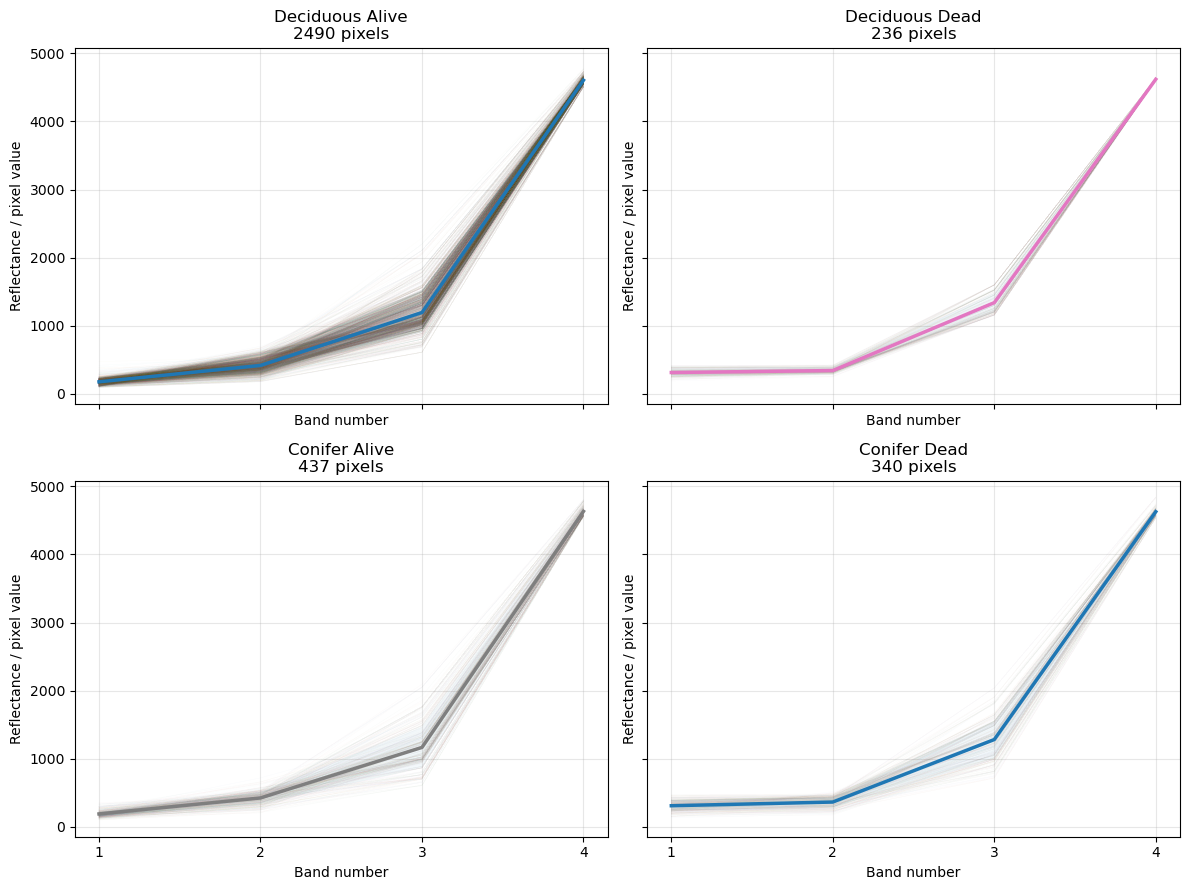

Saved plot to: /Volumes/External/OldFire/00_code/output/spectral_signatures_by_type_status.png

Mean spectral response by type/status:
        type status  n_pixels  mean_band_1  mean_band_2  mean_band_3  \
0  deciduous  alive      2490   177.058233   417.312048  1194.189558   
1  deciduous   dead       236   313.444915   342.309322  1339.436441   
2    conifer  alive       437   191.233410   425.821510  1167.414188   
3    conifer   dead       340   311.341176   365.538235  1283.082353   

   mean_band_4  std_band_1  std_band_2  std_band_3  std_band_4  
0  4604.480723   36.776239   89.903997  227.014559   39.910440  
1  4618.699153   48.785777   34.966474  144.644978   10.879471  
2  4632.885584   45.822416   83.518234  299.038046   62.864648  
3  4627.623529   73.250867   72.939429  280.030595   53.112140  

Saved mean spectral response table to: /Volumes/External/OldFire/00_code/output/mean_spectral_response_by_type_status.csv


In [25]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt


# -----------------------------
# User inputs
# -----------------------------

raster_path = "/Volumes/External/OldFire/reprojected_4326/rast_comp4band_261_EPSG4326.tif"
shapefile_path = "/Volumes/External/OldFire/reprojected_4326/trees_polygon_EPSG4326.shp"

output_dir = "/Volumes/External/OldFire/00_code/output"
os.makedirs(output_dir, exist_ok=True)

# Optional: replace these with real wavelengths if you know them.
# Example for Sentinel-2: [443, 490, 560, 665, 705, 740, 783, 842, 865, 1610, 2190]
wavelengths = None

# Maximum number of individual pixel spectra to draw per plot.
# This keeps plots readable and prevents huge files.
max_pixel_lines = 5000


# -----------------------------
# Helper function
# -----------------------------

def extract_pixels_for_group(src, polygons):
    """
    Extract valid pixel spectra from polygons for a multiband raster.

    Returns:
        pixels: array with shape (n_pixels, n_bands)
    """

    all_pixels = []

    for geom in polygons.geometry:
        try:
            out_image, out_transform = mask(
                src,
                [geom],
                crop=True,
                filled=True,
                nodata=src.nodata
            )
        except ValueError:
            # Polygon does not overlap raster
            continue

        # out_image shape: (bands, rows, cols)
        n_bands, rows, cols = out_image.shape

        # Reshape to: (pixels, bands)
        pixel_values = out_image.reshape(n_bands, rows * cols).T

        # Remove nodata pixels
        if src.nodata is not None:
            valid_mask = ~np.any(pixel_values == src.nodata, axis=1)
            pixel_values = pixel_values[valid_mask]

        # Remove NaN or infinite pixels
        valid_mask = np.all(np.isfinite(pixel_values), axis=1)
        pixel_values = pixel_values[valid_mask]

        # Remove pixels that are all zero, often background after masking
        nonzero_mask = ~np.all(pixel_values == 0, axis=1)
        pixel_values = pixel_values[nonzero_mask]

        if pixel_values.size > 0:
            all_pixels.append(pixel_values)

    if len(all_pixels) == 0:
        return np.empty((0, src.count))

    return np.vstack(all_pixels)


# -----------------------------
# Main script
# -----------------------------

# Read shapefile
gdf = gpd.read_file(shapefile_path)

# Make column names lowercase just in case
gdf.columns = [col.lower() for col in gdf.columns]

required_columns = ["type", "status"]
for col in required_columns:
    if col not in gdf.columns:
        raise ValueError(f"Missing required column: {col}")

# Clean category labels
gdf["type"] = gdf["type"].str.lower().str.strip()
gdf["status"] = gdf["status"].str.lower().str.strip()

groups = [
    ("deciduous", "alive"),
    ("deciduous", "dead"),
    ("conifer", "alive"),
    ("conifer", "dead")
]

# NEW: store summary results here
summary_rows = []

with rasterio.open(raster_path) as src:

    # Reproject shapefile if needed
    if gdf.crs != src.crs:
        print("Reprojecting shapefile to match raster CRS...")
        gdf = gdf.to_crs(src.crs)

    n_bands = src.count

    if wavelengths is None:
        x_values = np.arange(1, n_bands + 1)
        x_label = "Band number"
        band_names = [f"band_{i}" for i in range(1, n_bands + 1)]  # NEW
    else:
        if len(wavelengths) != n_bands:
            raise ValueError(
                f"Length of wavelengths list must match raster band count. "
                f"Raster has {n_bands} bands, but wavelengths has {len(wavelengths)} values."
            )
        x_values = np.array(wavelengths)
        x_label = "Wavelength"
        band_names = [f"wavelength_{w}" for w in wavelengths]  # NEW

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, (veg_type, status) in zip(axes, groups):

        group_gdf = gdf[
            (gdf["type"] == veg_type) &
            (gdf["status"] == status)
        ]

        if group_gdf.empty:
            ax.set_title(f"{veg_type.title()} {status.title()}\nNo polygons found")
            ax.set_xlabel(x_label)
            ax.set_ylabel("Reflectance / pixel value")
            continue

        pixels = extract_pixels_for_group(src, group_gdf)

        if pixels.shape[0] == 0:
            ax.set_title(f"{veg_type.title()} {status.title()}\nNo valid pixels")
            ax.set_xlabel(x_label)
            ax.set_ylabel("Reflectance / pixel value")
            continue

        mean_signature = np.nanmean(pixels, axis=0)
        std_signature = np.nanstd(pixels, axis=0)

        # NEW: save mean spectral response for this type/status group
        summary_row = {
            "type": veg_type,
            "status": status,
            "n_pixels": pixels.shape[0]
        }

        for band_name, mean_value in zip(band_names, mean_signature):
            summary_row[f"mean_{band_name}"] = mean_value

        for band_name, std_value in zip(band_names, std_signature):
            summary_row[f"std_{band_name}"] = std_value

        summary_rows.append(summary_row)

        # Draw individual pixel spectra lightly
        if pixels.shape[0] > max_pixel_lines:
            sample_indices = np.random.choice(
                pixels.shape[0],
                size=max_pixel_lines,
                replace=False
            )
            pixels_to_plot = pixels[sample_indices]
        else:
            pixels_to_plot = pixels

        for pixel in pixels_to_plot:
            ax.plot(x_values, pixel, linewidth=0.4, alpha=0.02)

        # Draw mean and standard deviation
        ax.plot(
            x_values,
            mean_signature,
            linewidth=2.5,
            label="Mean signature"
        )

        ax.fill_between(
            x_values,
            mean_signature - std_signature,
            mean_signature + std_signature,
            alpha=0.05,
            label="±1 std. dev."
        )

        ax.set_title(
            f"{veg_type.title()} {status.title()}\n"
            f"{pixels.shape[0]} pixels"
        )
        ax.set_xlabel(x_label)
        ax.set_ylabel("Reflectance / pixel value")
        ax.set_xticks([1, 2, 3, 4])
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    output_plot = os.path.join(output_dir, "spectral_signatures_by_type_status.png")
    plt.savefig(output_plot, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved plot to: {output_plot}")


# -----------------------------
# NEW: Export mean spectral response table
# -----------------------------

summary_df = pd.DataFrame(summary_rows)

output_csv = os.path.join(output_dir, "mean_spectral_response_by_type_status.csv")
summary_df.to_csv(output_csv, index=False)

print("\nMean spectral response by type/status:")
print(summary_df)

print(f"\nSaved mean spectral response table to: {output_csv}")

In [22]:
import os
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from rasterio.plot import show
from shapely.geometry import box

# -----------------------------
# User inputs
# -----------------------------

rgb_tif = "/Volumes/External/OldFire/reprojected_4326/ge_2003_mosaic (1)_EPSG4326.tif"
shapefile = "/Volumes/External/OldFire/shapefiles/trees_polygon.shp"

output_folder = "/Volumes/External/OldFire/Tree_plots"
os.makedirs(output_folder, exist_ok=True)

name_field = None

# -----------------------------
# Open RGB raster
# -----------------------------

with rasterio.open(rgb_tif) as src:
    raster_crs = src.crs
    raster_bounds = src.bounds

    # Read RGB bands
    # Assumes bands 1, 2, 3 are Red, Green, Blue
    rgb = src.read([1, 2, 3])

    # Convert raster bounds to polygon
    raster_extent_geom = box(
        raster_bounds.left,
        raster_bounds.bottom,
        raster_bounds.right,
        raster_bounds.top
    )

    # -----------------------------
    # Read shapefile
    # -----------------------------

    gdf = gpd.read_file(shapefile)

    if gdf.empty:
        raise ValueError("The shapefile is empty.")

    if gdf.crs is None:
        raise ValueError("The shapefile has no CRS. Define its CRS before running this script.")

    # Reproject shapefile to raster CRS if needed
    if gdf.crs != raster_crs:
        gdf = gdf.to_crs(raster_crs)

    # Keep only polygons that intersect the raster
    gdf = gdf[gdf.intersects(raster_extent_geom)].copy()

    if gdf.empty:
        raise ValueError("No polygons intersect the RGB raster extent.")

    # -----------------------------
    # Plot each polygon
    # -----------------------------

    for idx, row in gdf.iterrows():
        geom = row.geometry

        if geom is None or geom.is_empty:
            continue

        poly_type = clean_filename(row["type"])
        poly_status = clean_filename(row["status"])

        output_name = f"{poly_type}_{poly_status}_polygon_{idx:03d}.png"
        output_path = os.path.join(output_folder, output_name)

        fig, ax = plt.subplots(figsize=(10, 10))

        show(rgb, transform=src.transform, ax=ax)

        gpd.GeoSeries([geom], crs=gdf.crs).boundary.plot(
            ax=ax,
            color="yellow",
            linewidth=2
        )

        minx, miny, maxx, maxy = geom.bounds
        pad_x = (maxx - minx) * 3
        pad_y = (maxy - miny) * 3

        ax.set_xlim(minx - pad_x, maxx + pad_x)
        ax.set_ylim(miny - pad_y, maxy + pad_y)

        ax.set_title(f"Type: {row['type']} | Status: {row['status']}")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")

        plt.tight_layout()
        plt.savefig(output_path, dpi=300)
        plt.close(fig)

        print(f"Saved: {output_path}")

Saved: /Volumes/External/OldFire/Tree_plots/deciduous_alive_polygon_000.png
Saved: /Volumes/External/OldFire/Tree_plots/conifer_alive_polygon_001.png
Saved: /Volumes/External/OldFire/Tree_plots/conifer_dead_polygon_002.png
Saved: /Volumes/External/OldFire/Tree_plots/conifer_alive_polygon_003.png
Saved: /Volumes/External/OldFire/Tree_plots/conifer_alive_polygon_004.png
Saved: /Volumes/External/OldFire/Tree_plots/conifer_dead_polygon_005.png
Saved: /Volumes/External/OldFire/Tree_plots/conifer_alive_polygon_006.png
Saved: /Volumes/External/OldFire/Tree_plots/conifer_alive_polygon_007.png
Saved: /Volumes/External/OldFire/Tree_plots/conifer_dead_polygon_008.png
Saved: /Volumes/External/OldFire/Tree_plots/deciduous_alive_polygon_009.png
Saved: /Volumes/External/OldFire/Tree_plots/conifer_alive_polygon_010.png
Saved: /Volumes/External/OldFire/Tree_plots/conifer_dead_polygon_011.png
Saved: /Volumes/External/OldFire/Tree_plots/conifer_dead_polygon_012.png
Saved: /Volumes/External/OldFire/Tree_p

In [24]:
import os
import re
import numpy as np
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from shapely.geometry import box


# -----------------------------
# User inputs
# -----------------------------

thermal_tif = "/Volumes/External/OldFire/reprojected_4326/rast_comp4band_261_EPSG4326.tif"
shapefile = "/Volumes/External/OldFire/shapefiles/trees_polygon.shp"
output_folder = "/Volumes/External/OldFire/Thermal_Tree_plots"


extent_padding = 3.0  # larger number = wider background around polygon

cmap = "inferno"

# Use either "fixed" or "percentile"
stretch_type = "percentile"

fixed_vmin = 0
fixed_vmax = 4095

percentile_min = 2
percentile_max = 98


# -----------------------------
# Helper function
# -----------------------------

def clean_filename(value):
    value = str(value)
    value = value.strip()
    value = re.sub(r"[^\w\-]+", "_", value)
    value = re.sub(r"_+", "_", value)
    return value.strip("_")


# -----------------------------
# Create output folder
# -----------------------------

os.makedirs(output_folder, exist_ok=True)


# -----------------------------
# Open thermal raster
# -----------------------------

with rasterio.open(thermal_tif) as src:
    raster_crs = src.crs
    raster_bounds = src.bounds

    # Read all 4 thermal bands
    thermal = src.read([1, 2, 3, 4])

    raster_extent_geom = box(
        raster_bounds.left,
        raster_bounds.bottom,
        raster_bounds.right,
        raster_bounds.top
    )

    # -----------------------------
    # Calculate display stretches
    # -----------------------------

    band_stretches = {}

    for band_idx in range(4):
        band_data = thermal[band_idx]

        valid = band_data[np.isfinite(band_data)]

        # Optional: remove zeros if zero means no data in your image
        valid = valid[valid > 0]

        if stretch_type == "fixed":
            vmin = fixed_vmin
            vmax = fixed_vmax
        else:
            vmin = np.percentile(valid, percentile_min)
            vmax = np.percentile(valid, percentile_max)

        band_stretches[band_idx + 1] = {
            "vmin": vmin,
            "vmax": vmax
        }

        print(f"Band {band_idx + 1}: vmin={vmin:.2f}, vmax={vmax:.2f}")

    # -----------------------------
    # Read shapefile
    # -----------------------------

    gdf = gpd.read_file(shapefile)

    if gdf.empty:
        raise ValueError("The shapefile is empty.")

    if gdf.crs is None:
        raise ValueError("The shapefile has no CRS. Define its CRS before running this script.")

    if gdf.crs != raster_crs:
        gdf = gdf.to_crs(raster_crs)

    gdf = gdf[gdf.intersects(raster_extent_geom)].copy()

    if gdf.empty:
        raise ValueError("No polygons intersect the thermal raster extent.")

    # -----------------------------
    # Plot each polygon
    # -----------------------------

    for idx, row in gdf.iterrows():
        geom = row.geometry

        if geom is None or geom.is_empty:
            continue

        poly_type = clean_filename(row["type"])
        poly_status = clean_filename(row["status"])

        output_name = f"{poly_type}_{poly_status}_thermal_4bands_polygon_{idx:03d}.png"
        output_path = os.path.join(output_folder, output_name)

        fig, axes = plt.subplots(
            1,
            4,
            figsize=(20, 6),
            constrained_layout=True
        )

        minx, miny, maxx, maxy = geom.bounds
        pad_x = (maxx - minx) * extent_padding
        pad_y = (maxy - miny) * extent_padding

        xlim = (minx - pad_x, maxx + pad_x)
        ylim = (miny - pad_y, maxy + pad_y)

        for band_idx, ax in enumerate(axes):
            band_number = band_idx + 1
            band_data = thermal[band_idx]

            img = ax.imshow(
                band_data,
                cmap=cmap,
                vmin=band_stretches[band_number]["vmin"],
                vmax=band_stretches[band_number]["vmax"],
                extent=[
                    raster_bounds.left,
                    raster_bounds.right,
                    raster_bounds.bottom,
                    raster_bounds.top
                ]
            )

            gpd.GeoSeries([geom], crs=gdf.crs).boundary.plot(
                ax=ax,
                color="cyan",
                linewidth=2
            )

            ax.set_xlim(xlim)
            ax.set_ylim(ylim)

            ax.set_title(f"Band {band_number}")
            ax.set_xlabel("X")
            ax.set_ylabel("Y")

            cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label("Thermal DN")

        fig.suptitle(
            f"Type: {row['type']} | Status: {row['status']}",
            fontsize=16
        )

        plt.savefig(output_path, dpi=300)
        plt.close(fig)

        print(f"Saved: {output_path}")

print("Done.")

Band 1: vmin=88.00, vmax=597.00
Band 2: vmin=127.00, vmax=585.00
Band 3: vmin=418.00, vmax=3050.00
Band 4: vmin=4506.00, vmax=4964.00
Saved: /Volumes/External/OldFire/Thermal_Tree_plots/deciduous_alive_thermal_4bands_polygon_000.png
Saved: /Volumes/External/OldFire/Thermal_Tree_plots/conifer_alive_thermal_4bands_polygon_001.png
Saved: /Volumes/External/OldFire/Thermal_Tree_plots/conifer_dead_thermal_4bands_polygon_002.png
Saved: /Volumes/External/OldFire/Thermal_Tree_plots/conifer_alive_thermal_4bands_polygon_003.png
Saved: /Volumes/External/OldFire/Thermal_Tree_plots/conifer_alive_thermal_4bands_polygon_004.png
Saved: /Volumes/External/OldFire/Thermal_Tree_plots/conifer_dead_thermal_4bands_polygon_005.png
Saved: /Volumes/External/OldFire/Thermal_Tree_plots/conifer_alive_thermal_4bands_polygon_006.png
Saved: /Volumes/External/OldFire/Thermal_Tree_plots/conifer_alive_thermal_4bands_polygon_007.png
Saved: /Volumes/External/OldFire/Thermal_Tree_plots/conifer_dead_thermal_4bands_polygon_00